In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
csv_path = "../csv/raw_data/flow_density_runs_20_start_4_tph_600_window_100.csv"

df = pd.read_csv(csv_path)
df.head()

,run_id,road_id,time,avg_system_cars,window_flow_count,flow_per_tick,road_density,avg_speed_road
0,1,"(0,4)",4:09,21,3,0.03,0.074722,0.539234
1,1,"(0,3)",4:09,21,4,0.04,0.049167,0.533514
2,1,"(0,2)",4:09,21,2,0.02,0.049444,0.508657
3,1,"(0,1)",4:09,21,2,0.02,0.024722,0.579798
4,1,"(0,0)",4:09,21,2,0.02,0.024444,0.555898


In [5]:
# keep only valid rows
plot_df = df.copy()

plot_df = plot_df[(plot_df["avg_speed_road"] > 0) | (plot_df["flow_per_tick"] > 0)]

# remove rows where speed is missing
plot_df = plot_df.dropna(subset=["flow_per_tick", "avg_speed_road"])

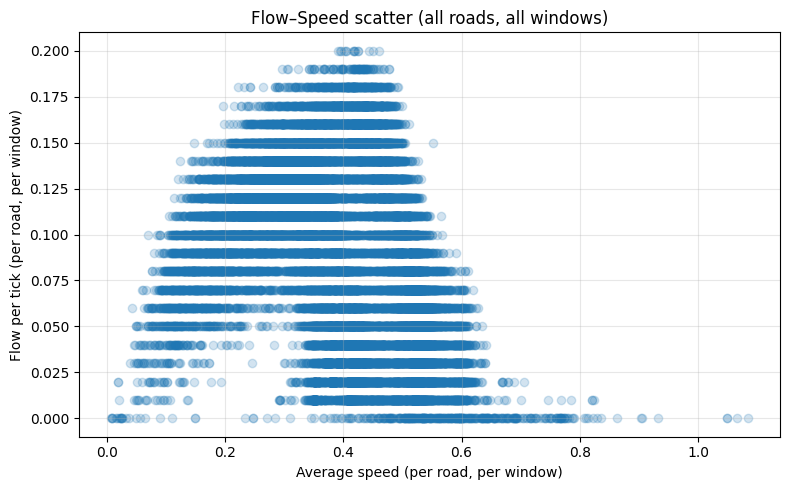

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(plot_df["avg_speed_road"], plot_df["flow_per_tick"], alpha=0.2)

plt.xlabel("Average speed (per road, per window)")
plt.ylabel("Flow per tick (per road, per window)")
plt.title("Flow–Speed scatter (all roads, all windows)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

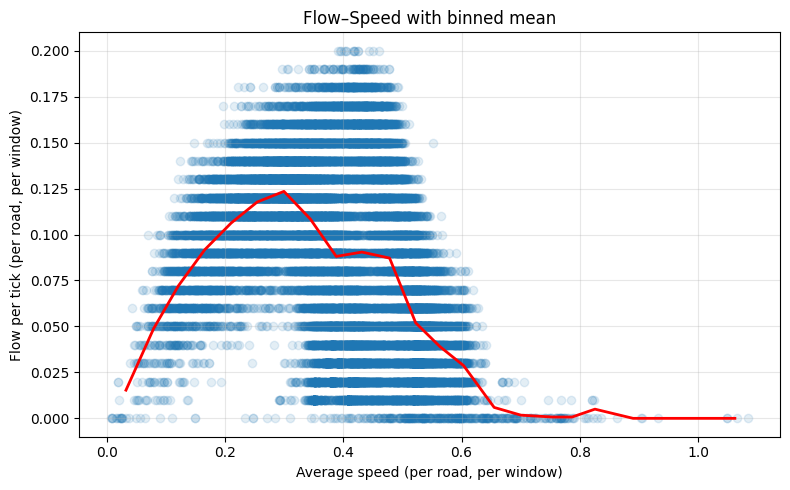

,speed_mid,flow_mean,n
speed_bin,,,
"(0.00644, 0.0514]",0.032339,0.015333,30
"(0.0514, 0.0963]",0.079181,0.048851,148
"(0.0963, 0.141]",0.121110,0.072134,506
"(0.141, 0.186]",0.165599,0.091730,1000
"(0.186, 0.231]",0.210236,0.106237,1483


In [7]:

tmp = plot_df.copy()

# define bins on speed
bins = np.linspace(tmp["avg_speed_road"].min(), tmp["avg_speed_road"].max(), 25)
tmp["speed_bin"] = pd.cut(tmp["avg_speed_road"], bins)

binned = (
    tmp.groupby("speed_bin", observed=True)
      .agg(speed_mid=("avg_speed_road", "mean"),
           flow_mean=("flow_per_tick", "mean"),
           n=("flow_per_tick", "size"))
      .dropna()
)

plt.figure(figsize=(8, 5))
plt.scatter(tmp["avg_speed_road"], tmp["flow_per_tick"], alpha=0.12)
plt.plot(binned["speed_mid"], binned["flow_mean"], linewidth=2, color="red")

plt.xlabel("Average speed (per road, per window)")
plt.ylabel("Flow per tick (per road, per window)")
plt.title("Flow–Speed with binned mean")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

binned.head()


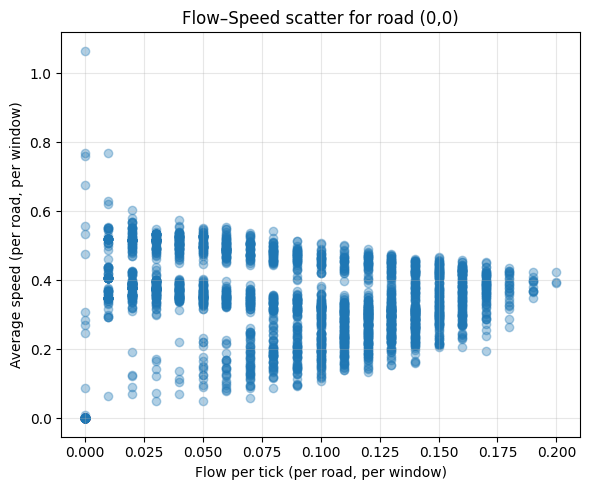

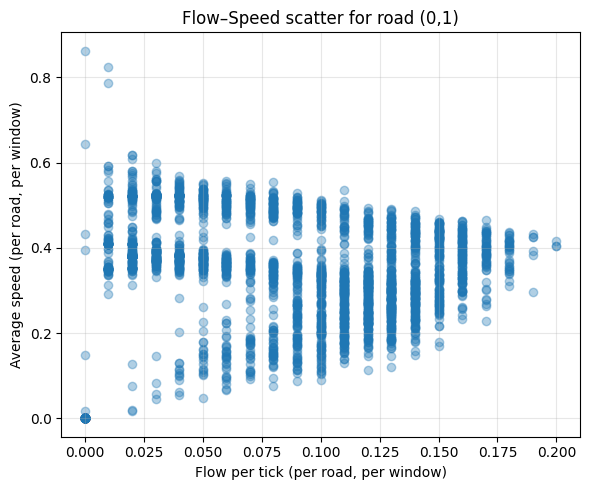

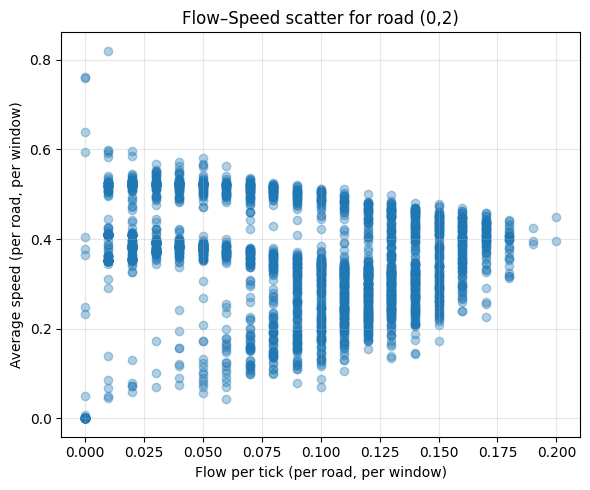

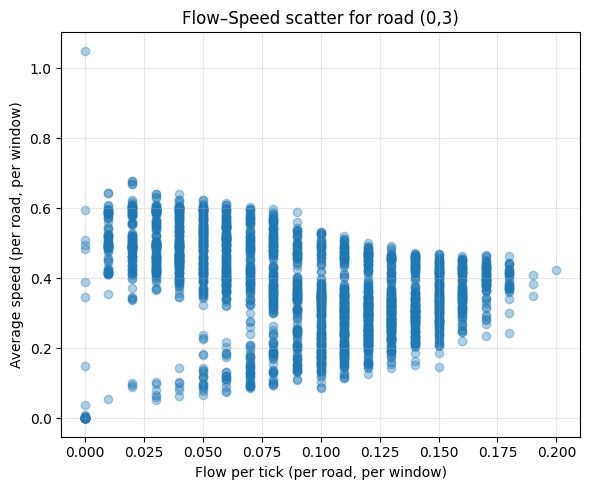

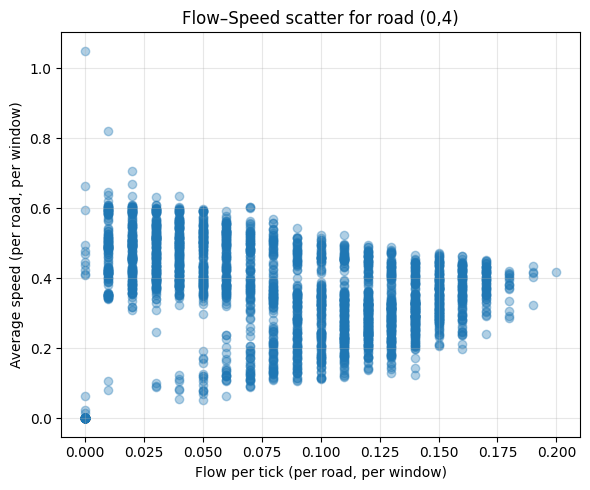

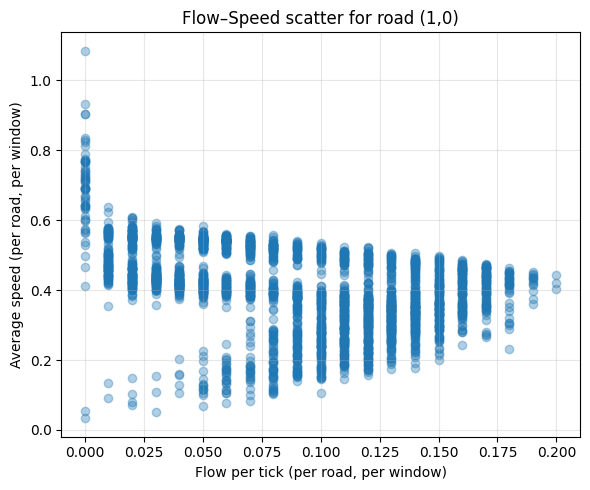

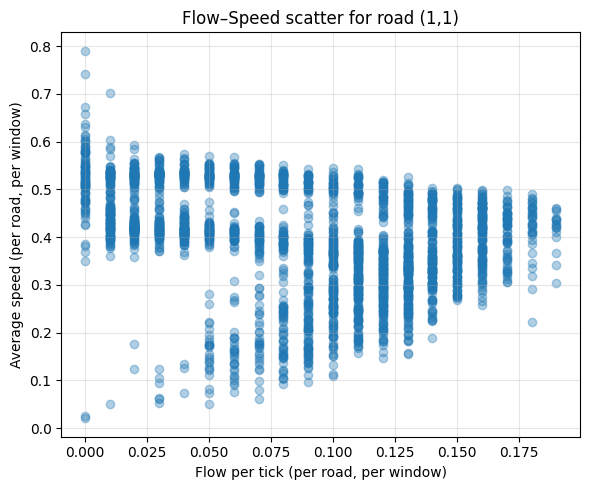

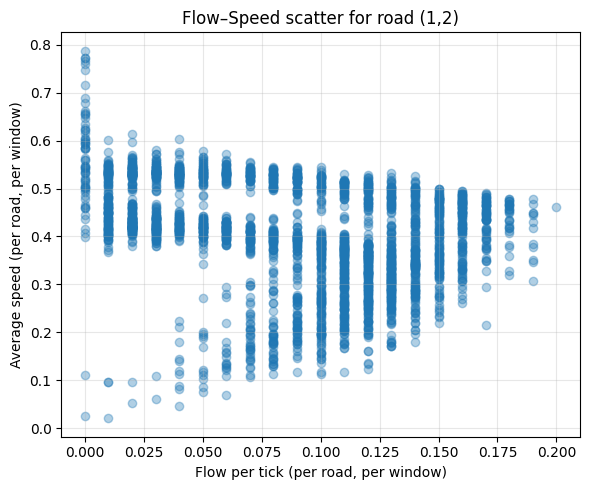

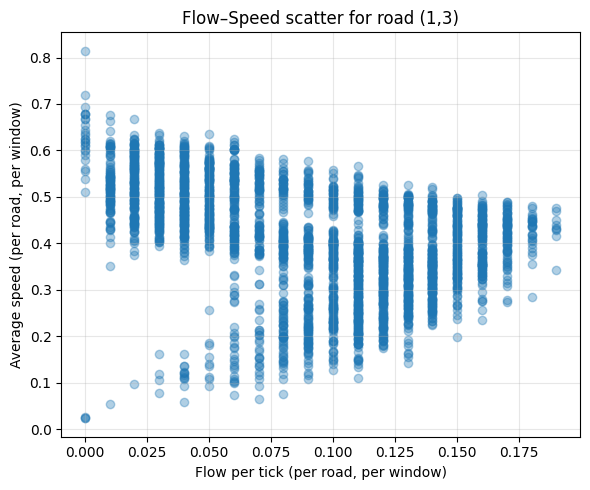

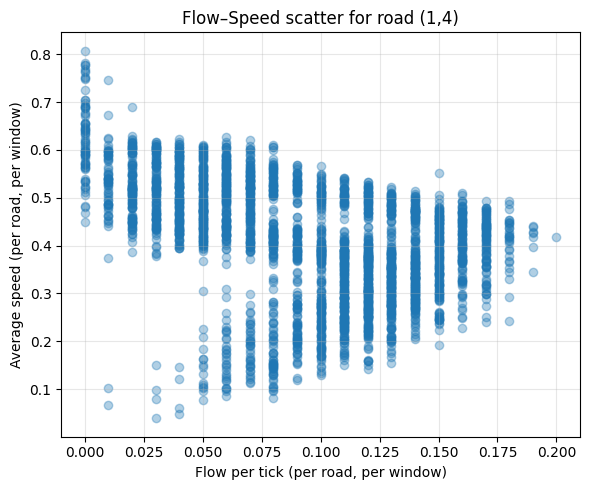

In [8]:
road_ids = sorted(df["road_id"].unique())
len(road_ids), road_ids

for rid in road_ids:
    sub = df[df["road_id"] == rid]

    plt.figure(figsize=(6, 5))
    plt.scatter(
        sub["flow_per_tick"],
        sub["avg_speed_road"],
        alpha=0.35
    )

    plt.xlabel("Flow per tick (per road, per window)")
    plt.ylabel("Average speed (per road, per window)")
    plt.title(f"Flow–Speed scatter for road {rid}")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [9]:
capacity = (
    df.groupby("road_id", as_index=False)
      .agg(
          max_flow=("window_flow_count", "max"),      # capacity as max camera count per window
          flow_per_tick=("flow_per_tick", "max"),     # consistent with max_flow (usually max_flow/window_ticks)
      )
      .sort_values("road_id")
)
capacity


,road_id,max_flow,flow_per_tick
0,"(0,0)",20,0.20
1,"(0,1)",20,0.20
2,"(0,2)",20,0.20
3,"(0,3)",20,0.20
4,"(0,4)",20,0.20
5,"(1,0)",20,0.20
6,"(1,1)",19,0.19
7,"(1,2)",20,0.20
8,"(1,3)",19,0.19
9,"(1,4)",20,0.20


In [10]:
capacity.to_csv("../csv/explored_data/capacity_per_road.csv", index=False)
